In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


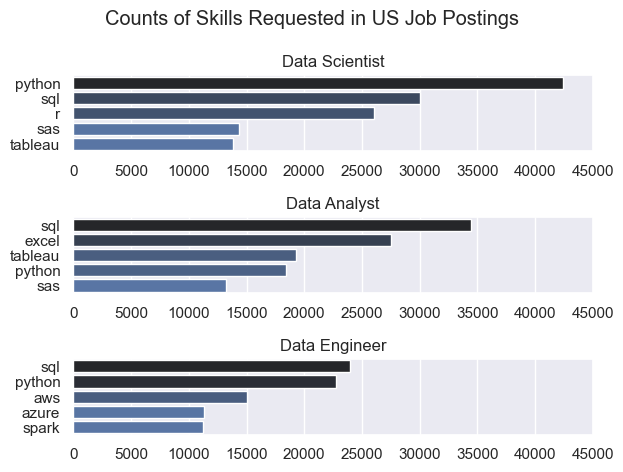

In [7]:
df_US = df[df['job_country'] == 'United States']

df_US = df_US.explode('job_skills')

df_skills = (
    df_US.groupby(['job_title_short', 'job_skills'])
    .size()
    .reset_index(name = 'skill_count')
    .sort_values(by='skill_count', ascending= False)
)


job_title = df_skills['job_title_short'].unique()[:3]

fig, ax = plt.subplots(len(job_title), 1)

sns.set_theme(style='darkgrid')

for i, job in enumerate(job_title):
    df_plot = (
        df_skills[df_skills['job_title_short'] == job]
        .sort_values(by = 'skill_count', ascending = False)
        .head(5) 
    ) 
    
    sns.barplot(
        data = df_plot,
        y= 'job_skills',
        x= 'skill_count',
        ax = ax[i],
        legend= False,
        hue= 'skill_count',
        palette="dark:b_r"
    ) 
    
    ax[i].set_title(job) 
    ax[i].set_xlabel('') 
    ax[i].set_ylabel('') 
    ax[i].set_xlim(0, 45000) 

fig.suptitle('Counts of Skills Requested in US Job Postings') 
fig.tight_layout() 
plt.show()